## Potrzebne biblioteki

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import torchvision
from torchvision import transforms, datasets

## Wybór urządzenia

In [8]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Used device: {device}")

Used device: cuda


## Zbiór danych

In [9]:
!unzip -q trafic_32.zip

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
dataset = datasets.ImageFolder("trafic_32", transform=transform)


## Rozkład próbek w klasach

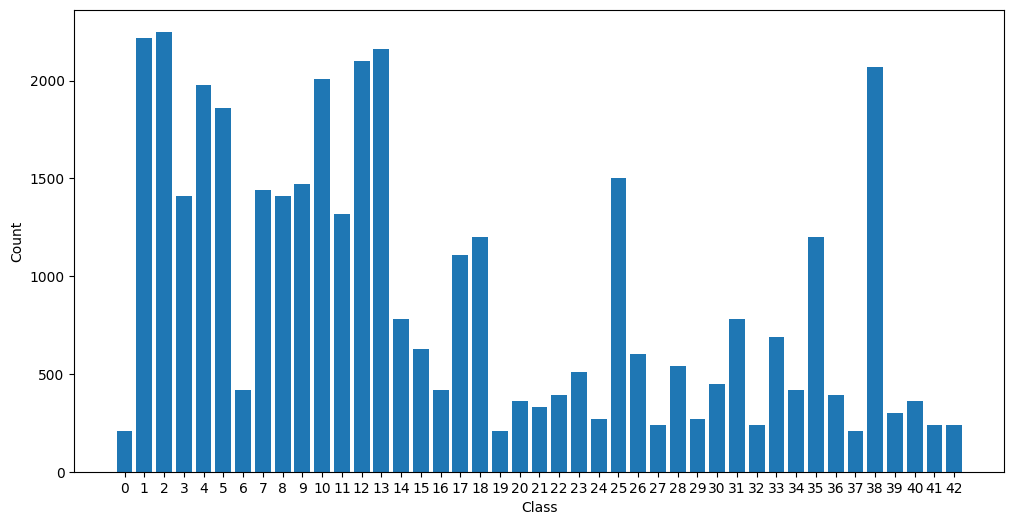

In [11]:
class_counts = Counter(dataset.targets)

classes = list(class_counts.keys())
counts = [class_counts[c] for c in classes]

plt.figure(figsize=(12, 6))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(classes)
plt.show()

## Ważenie próbek

In [12]:
counts = np.bincount(dataset.targets)
weights = 1.0 / counts

sample_weights = [weights[t] for t in dataset.targets]

sampler = data.WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

dataloader = data.DataLoader(dataset, batch_size=128, sampler=sampler)

## Architektura modelu dyfuzyjnego (DDPM)

In [13]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb = np.log(10000.0) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm_1 = nn.GroupNorm(8, in_ch)
        self.conv_1 = nn.Conv2d(in_ch, out_ch, 3, 1, 1)

        self.time_mlp = nn.Linear(time_dim, out_ch)

        self.norm_2 = nn.GroupNorm(8, out_ch)
        self.conv_2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1)

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, t):
        h = self.conv_1(self.act(self.norm_1(x)))
        h = h + self.time_mlp(self.act(t))[:, :, None, None]
        h = self.conv_2(self.act(self.norm_2(h)))
        return h + self.skip(x)

In [14]:
class UNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, time_dim=256):
        super(UNet, self).__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(hidden_dim),
            nn.Linear(hidden_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.conv_in = nn.Conv2d(input_dim, hidden_dim, 3, 1, 1)

        self.down_1 = ResBlock(hidden_dim, hidden_dim, time_dim)
        self.pool_1 = nn.Conv2d(hidden_dim, hidden_dim, 4, 2, 1)

        self.down_2 = ResBlock(hidden_dim, hidden_dim * 2, time_dim)
        self.pool_2 = nn.Conv2d(hidden_dim * 2, hidden_dim * 2, 4, 2, 1)

        self.down_3 = ResBlock(hidden_dim * 2, hidden_dim * 4, time_dim)

        self.mid_1 = ResBlock(hidden_dim * 4, hidden_dim * 4, time_dim)
        self.mid_2 = ResBlock(hidden_dim * 4, hidden_dim * 4, time_dim)

        self.up_3 = ResBlock(hidden_dim * 4 + hidden_dim * 4, hidden_dim * 2, time_dim)
        self.up_sample_3 = nn.ConvTranspose2d(hidden_dim * 2, hidden_dim * 2, 4, 2, 1)

        self.up_2 = ResBlock(hidden_dim * 2 + hidden_dim * 2, hidden_dim, time_dim)
        self.up_sample_2 = nn.ConvTranspose2d(hidden_dim, hidden_dim, 4, 2, 1)

        self.up_1 = ResBlock(hidden_dim + hidden_dim, hidden_dim, time_dim)

        self.norm_out = nn.GroupNorm(8, hidden_dim)
        self.conv_out = nn.Conv2d(hidden_dim, input_dim, 3, 1, 1)
        self.act = nn.SiLU()

    def forward(self, x, t):
        t = self.time_mlp(t)

        x = self.conv_in(x)

        d1 = self.down_1(x, t)
        d2 = self.down_2(self.pool_1(d1), t)
        d3 = self.down_3(self.pool_2(d2), t)

        m = self.mid_1(d3, t)
        m = self.mid_2(m, t)

        u3 = self.up_3(torch.cat([m, d3], dim=1), t)
        u3 = self.up_sample_3(u3)

        u2 = self.up_2(torch.cat([u3, d2], dim=1), t)
        u2 = self.up_sample_2(u2)

        u1 = self.up_1(torch.cat([u2, d1], dim=1), t)

        return self.conv_out(self.act(self.norm_out(u1)))

In [15]:
class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, img_size=32, channels=3, device="cpu"):
        self.T = T
        self.img_size = img_size
        self.channels = channels
        self.device = device

        self.beta = torch.linspace(beta_start, beta_end, T, device=device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def q_sample(self, x_0, t, noise):
        # Zaszumianie obrazka x_0 do kroku t
        sqrt_alpha_bar = torch.sqrt(self.alpha_bar[t])[:, None, None, None]
        sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar[t])[:, None, None, None]
        return sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise

    def sample_timesteps(self, n):
        return torch.randint(0, self.T, (n,), device=self.device)

    @torch.no_grad()
    def sample(self, model, n):
        model.eval()
        x = torch.randn(n, self.channels, self.img_size, self.img_size, device=self.device)
        for i in reversed(range(self.T)):
            t = torch.full((n,), i, device=self.device, dtype=torch.long)
            predicted_noise = model(x, t)

            alpha = self.alpha[i]
            alpha_bar = self.alpha_bar[i]
            beta = self.beta[i]

            if i > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = 1.0 / torch.sqrt(alpha) * (
                x - (1.0 - alpha) / torch.sqrt(1.0 - alpha_bar) * predicted_noise
            ) + torch.sqrt(beta) * noise
        model.train()
        return x

## Inicjalizacja sieci

In [16]:
hidden_dim = 64
channels = 3
num_classes = len(dataset.class_to_idx)
T = 1000

model = UNet(input_dim=channels, hidden_dim=hidden_dim).to(device)

diffusion = Diffusion(T=T, img_size=32, channels=channels, device=device)

model_optimizer = optim.Adam(model.parameters(), lr=0.0002, betas=(0.5, 0.999))
model_scheduler = optim.lr_scheduler.ExponentialLR(optimizer=model_optimizer, gamma=0.99)

criterion = nn.MSELoss()

## Pętla treningowa

In [ ]:
losses = []
num_epochs = 100
for epoch in range(num_epochs):
    epoch_losses = []
    for i, batch in enumerate(dataloader, 0):
        ####################
        # Update U-Net     #
        ####################

        model_optimizer.zero_grad()

        real_images = batch[0].to(device)
        b_size = real_images.size(0)

        t = diffusion.sample_timesteps(b_size)
        noise = torch.randn_like(real_images)
        noisy_images = diffusion.q_sample(real_images, t, noise)

        predicted_noise = model(noisy_images, t)
        loss = criterion(predicted_noise, noise)

        loss.backward()
        model_optimizer.step()

        epoch_losses.append(loss.item())
        losses.append(loss.item())

        if i % 10 == 0:
            print(f"Batch: {i}/{len(dataloader)}, Loss: {loss.item():.4f}")

    print(f"Epoch: {epoch}, loss: {np.mean(epoch_losses):.4}")
    model_scheduler.step()

    if epoch % 10 == 0:
        with torch.no_grad():
            fake = diffusion.sample(model, 16).detach().cpu()
        fake = (fake.clamp(-1, 1) + 1) / 2
        grid = torchvision.utils.make_grid(fake)
        grid = grid.permute(1, 2, 0)
        plt.figure(figsize=(10, 10))
        plt.title(f"Generations")
        plt.imshow(grid)
        plt.axis("off")
        plt.show()

Batch: 0/307, Loss: 1.1535
Batch: 10/307, Loss: 0.4276
Batch: 20/307, Loss: 0.2251
Batch: 30/307, Loss: 0.1781
Batch: 40/307, Loss: 0.1559
Batch: 50/307, Loss: 0.1340
Batch: 60/307, Loss: 0.1271
Batch: 70/307, Loss: 0.1051
Batch: 80/307, Loss: 0.1190
Batch: 90/307, Loss: 0.0777


## Generowanie 1000 próbek

In [ ]:
n_samples = 1000
batch_size = 100

generated_chunks = []
for _ in range(n_samples // batch_size):
    samples = diffusion.sample(model, batch_size)

    samples = (samples.clamp(-1, 1) + 1) / 2
    generated_chunks.append(samples.cpu())

generated_imgs = torch.cat(generated_chunks, dim=0)
print(generated_imgs.shape)

grid = torchvision.utils.make_grid(generated_imgs[:64], nrow=8)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

torch.save(generated_imgs.cpu().detach(), "poniedzialek_nazwisko1_nazwisko2.pt")